In [12]:
import os
import re
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [13]:
def extract_job_number(log_path : str) -> int :
    x = log_path.split('_')[0]
    return int(x.strip('output/'))

In [14]:
all_log_files = ['output/' + x for x in os.listdir('output/')]
all_log_files

['output/19341918_output.log',
 'output/19366178_output_f_2000_clients_2.log',
 'output/19374281_output_p_500_clients_2.log',
 'output/19365984_output_f_2000_clients_2.log',
 'output/19360472_output_f_4000_clients_2.log',
 'output/19352478_output_f_4000.log',
 'output/19341978_output_f_20.log',
 'output/19363499_output_f_2555_clients_2.log',
 'output/19367671_output_f_17500_clients_100.log',
 'output/19365982_output_f_800_clients_2.log',
 'output/19342006_output.log',
 'output/19365979_output_f_100_clients_2.log',
 'output/19374156_output_f_1000_clients_2.log',
 'output/19374140_output_f_1000_clients_2.log',
 'output/19365977_output_f_1_clients_2.log',
 'output/19331300_output.log',
 'output/19331290_output.log',
 'output/19366182_output_f_8000_clients_2.log',
 'output/19341984_output_f_1000.log',
 'output/19367673_output_f_2000_clients_10_0.log',
 'output/19366180_output_f_10000_clients_2.log',
 'output/19331286_output.log',
 'output/19366357_output_f_12000_clients_10.log',
 'output/1

In [15]:
cut_off = 19374122
log_files = [x for x in all_log_files if extract_job_number(x) >= cut_off]
log_files

['output/19374281_output_p_500_clients_2.log',
 'output/19374156_output_f_1000_clients_2.log',
 'output/19374140_output_f_1000_clients_2.log',
 'output/19374139_output_f_1000_clients_2.log',
 'output/19374289_output_p_1000000_clients_2.log',
 'output/19374136_output_f_1000_clients_2.log',
 'output/19374282_output_p_1000_clients_2.log',
 'output/19374283_output_p_5000_clients_2.log',
 'output/19374280_output_p_100_clients_2.log',
 'output/19374303_output_p_500000_clients_2.log',
 'output/19374240_output_p_10_clients_2.log',
 'output/19374122_output_f_1000_clients_2.log',
 'output/19374241_output_p_50_clients_2.log',
 'output/19374284_output_p_10000_clients_2.log']

In [16]:
ps = {}
for x in log_files:
    if '_p_' in x:
        continue
    else:
        ps[x] = 0
ps

{'output/19374156_output_f_1000_clients_2.log': 0,
 'output/19374140_output_f_1000_clients_2.log': 0,
 'output/19374139_output_f_1000_clients_2.log': 0,
 'output/19374136_output_f_1000_clients_2.log': 0,
 'output/19374122_output_f_1000_clients_2.log': 0}

In [23]:
ps = {
 'output/19374289_output_p_1000000_clients_2.log': 1000000,
 'output/19374156_output_f_1000_clients_2.log': 10,
 'output/19374140_output_f_1000_clients_2.log': 100000,
 'output/19374139_output_f_1000_clients_2.log': 10000,
 'output/19374136_output_f_1000_clients_2.log': 1000,
 'output/19374122_output_f_1000_clients_2.log': 0
 }

In [24]:
def extract_eval_acc(file_path):
    # Regex to find eval_acc values
    pattern = r"eval_acc=(\d+\.\d+)"
    
    # Open file and read contents
    with open(file_path, 'r') as file:
        log_text = file.read()
    
    # Find all matches in the log text
    matches = re.findall(pattern, log_text)
    
    # Convert matches to float, skipping the first occurrence
    eval_acc_values = [float(acc) for acc in matches[1:]] if len(matches) > 1 else []
    
    return eval_acc_values


In [25]:
accuracies = {}
for log_file, p in ps.items():
    values = extract_eval_acc(log_file)
    accuracies[f'p={p}'] = values
accuracies

{'p=1000000': [0.104,
  0.11,
  0.11,
  0.109,
  0.109,
  0.116,
  0.116,
  0.117,
  0.117,
  0.112,
  0.112,
  0.115,
  0.115,
  0.116,
  0.116,
  0.116,
  0.116,
  0.119,
  0.119,
  0.111,
  0.111,
  0.12,
  0.12,
  0.123,
  0.123,
  0.125,
  0.125,
  0.12,
  0.12,
  0.121,
  0.121,
  0.125,
  0.125,
  0.134,
  0.134,
  0.138,
  0.138,
  0.141,
  0.141,
  0.146,
  0.146,
  0.158,
  0.158,
  0.169,
  0.169,
  0.168,
  0.168,
  0.176,
  0.176,
  0.175,
  0.175,
  0.186,
  0.186,
  0.186,
  0.186,
  0.185,
  0.185,
  0.184,
  0.184,
  0.188,
  0.188,
  0.192,
  0.192,
  0.192,
  0.192,
  0.2,
  0.2,
  0.205,
  0.205,
  0.208,
  0.208,
  0.211,
  0.211,
  0.219,
  0.219,
  0.217,
  0.217,
  0.224,
  0.224,
  0.213,
  0.213,
  0.229,
  0.229,
  0.234,
  0.234,
  0.232,
  0.232,
  0.236,
  0.236,
  0.232,
  0.232,
  0.237,
  0.237,
  0.254,
  0.254,
  0.248,
  0.248,
  0.257,
  0.257,
  0.254,
  0.254,
  0.253,
  0.253,
  0.263,
  0.263,
  0.249,
  0.249,
  0.257,
  0.257,
  0.272,
  0.272

In [26]:
df = pd.DataFrame.from_dict(accuracies, orient='index').transpose()
df.dropna(inplace=True)
df

,p=1000000,p=10,p=100000,p=10000,p=1000,p=0
0,0.104,0.097,0.101,0.100,0.104,0.100
1,0.110,0.101,0.110,0.104,0.111,0.107
2,0.110,0.101,0.110,0.104,0.111,0.107
3,0.109,0.101,0.130,0.123,0.123,0.117
4,0.109,0.101,0.130,0.123,0.123,0.117
...,...,...,...,...,...,...
994,0.490,0.101,0.499,0.495,0.490,0.496
995,0.488,0.101,0.492,0.496,0.486,0.490
996,0.488,0.101,0.492,0.496,0.486,0.490
997,0.487,0.101,0.494,0.497,0.488,0.497


In [27]:
cols = list(df.columns)
cols[-1] = 'No Error Compensation'
df.columns=cols
df

,p=1000000,p=10,p=100000,p=10000,p=1000,No Error Compensation
0,0.104,0.097,0.101,0.100,0.104,0.100
1,0.110,0.101,0.110,0.104,0.111,0.107
2,0.110,0.101,0.110,0.104,0.111,0.107
3,0.109,0.101,0.130,0.123,0.123,0.117
4,0.109,0.101,0.130,0.123,0.123,0.117
...,...,...,...,...,...,...
994,0.490,0.101,0.499,0.495,0.490,0.496
995,0.488,0.101,0.492,0.496,0.486,0.490
996,0.488,0.101,0.492,0.496,0.486,0.490
997,0.487,0.101,0.494,0.497,0.488,0.497


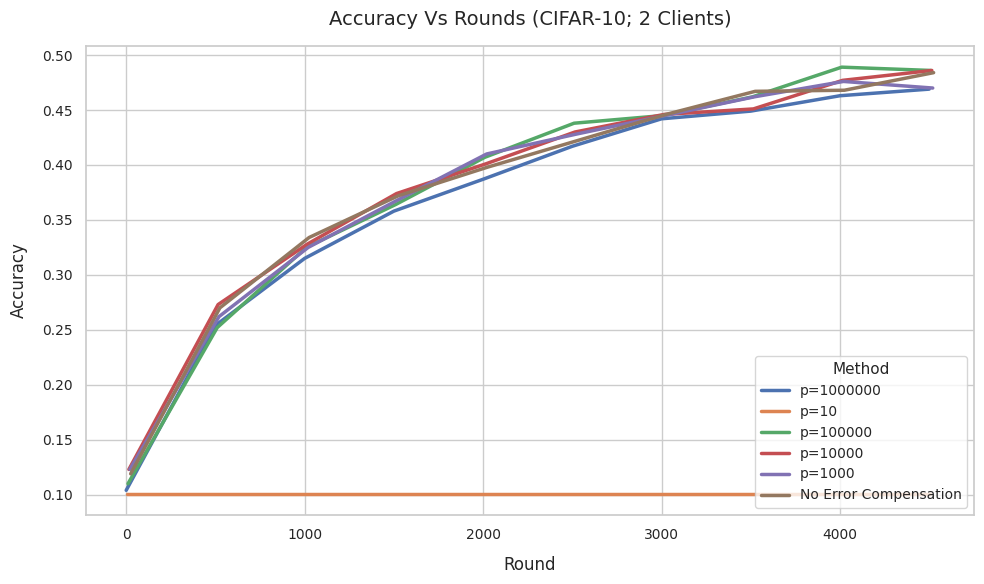

In [28]:
# Convert the DataFrame into long format
df_long = df.reset_index().melt(id_vars='index', var_name='q', value_name='value')

# Multiply the 'index' values by 10 to represent 'Rounds'
df_long['index'] = df_long['index'] * 5

# Sample the DataFrame by every 100th row
df_long_sampled = df_long.iloc[::100, :]

# Set the plot style to make it visually appealing
sns.set(style='whitegrid')  # Adds a clean grid background

# Create the line plot using seaborn
plt.figure(figsize=(10, 6))  # Adjust figure size for better presentation
sns.lineplot(data=df_long_sampled, x='index', y='value', hue='q', linewidth=2.5)

# Add labels and a title
plt.xlabel('Round', fontsize=12, labelpad=10)
plt.ylabel('Accuracy', fontsize=12, labelpad=10)
plt.title('Accuracy Vs Rounds (CIFAR-10; 2 Clients)', fontsize=14, pad=15)

# Customize the ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Add a legend
plt.legend(title='Method', fontsize=10, title_fontsize=11, loc='lower right')

# Show the plot
plt.tight_layout()
plt.show()